# **Food Price Inflation Prediction**

**Group Members**

1.   Sidra-Tul-Muntaha 084
2.   Sidra Liaqat 083

**Semester VI**



### **Methodology**

This program converts global commodity prices from USD to PKR using annual exchange rates. The dataset is first cleaned by removing invalid rows and ensuring proper numeric formatting. Prices are then converted by applying year-wise exchange rates. The final dataset is saved in CSV and Excel formats for further analysis.

---


In [ ]:
import pandas as pd

print("="*60)
print("🌍 LOADING GLOBAL PRICE DATA FROM GOOGLE DRIVE")
print("="*60)

# ============================================
# GOOGLE DRIVE FILE ID
# ============================================
FILE_ID = "1WA3UiNLumICaG1SucpKLwzZo2HsLppbM"

# Direct download URL for Excel format
url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"

print(f"\n📁 Accessing: Google Drive")
print(f"📄 File ID: {FILE_ID}")
print(f"📄 Sheet: Annual Prices (Real)")

# ============================================
# LOAD EXCEL FILE DIRECTLY
# ============================================
df = pd.read_excel(url, sheet_name="Annual Prices (Real)")

print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================
# PREVIEW THE DATA
# ============================================
print("\n" + "="*60)
print("📊 DATA PREVIEW")
print("="*60)

print("\n📋 First 5 rows:")
print(df.head())

print("\n📋 Column names:")
for i, col in enumerate(df.columns[:10]):
    print(f"   {i+1}. {col}")

print("\n📋 Last 5 rows:")
print(df.tail())

# ============================================
# DATA INFORMATION
# ============================================
print("\n" + "="*60)
print("📋 DATA INFORMATION")
print("="*60)

print(f"\nTotal rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n✅ Global price data loaded successfully!")

🌍 LOADING GLOBAL PRICE DATA FROM GOOGLE DRIVE

📁 Accessing: Google Drive
📄 File ID: 1WA3UiNLumICaG1SucpKLwzZo2HsLppbM
📄 Sheet: Annual Prices (Real)

✅ Data loaded successfully!
   Shape: 73 rows, 39 columns

📊 DATA PREVIEW

📋 First 5 rows:
    World Bank Commodity Price Data (The Pink Sheet) Unnamed: 1 Unnamed: 2  \
0  annual prices, 1960 to present, real 2010 US d...        NaN        NaN   
1  (annual series are available in nominal and re...        NaN        NaN   
2                          Updated on March 03, 2026        NaN        NaN   
3                                                NaN        NaN        NaN   
4                                                NaN        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3      

In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print(" USD TO PKR CONVERSION ONLY")
print("="*60)

# ============================================
#    Read Excel file - SKIP first 2 rows
# ============================================
file_name = "Global Price Data.xlsx"
sheet_name = "Annual Prices (Real)"

print(f"\n Reading: {file_name}")
print(f" Sheet: {sheet_name}")

# Skip first 2 rows (the description rows)
#df = pd.read_excel(file_name, sheet_name=sheet_name, skiprows=2)

print(f" Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================
#   MANUALLY SET ALL COLUMN NAMES
# ============================================
print("\n Setting column names manually...")

# Complete list of 39 commodity names (based on your earlier data)
column_names = [
    'Year',
    'Crude_oil_avg',
    'Crude_oil_Brent',
    'Crude_oil_Dubai',
    'Crude_oil_WTI',
    'Coal_Australian',
    'Coal_South_African',
    'Natural_gas_US',
    'Natural_gas_Europe',
    'LNG_Japan',
    'Natural_gas_index',
    'Cocoa',
    'Coffee_Arabica',
    'Coffee_Robusta',
    'Tea_avg_3_auctions',
    'Tea_Colombo',
    'Tea_Kolkata',
    'Tea_Mombasa',
    'Coconut_oil',
    'Groundnuts',
    'Fish_meal',
    'Groundnut_oil',
    'Palm_oil',
    'Palm_kernel_oil',
    'Soybeans',
    'Soybean_oil',
    'Soybean_meal',
    'Barley',
    'Maize',
    'Sorghum',
    'Rice_Thai_5%',
    'Rice_Thai_25%',
    'Rice_Thai_A1',
    'Rice_Vietnamese_5%',
    'Wheat_US_SRW',
    'Wheat_US_HRW',
    'Banana_Europe',
    'Banana_US',
    'Orange',
    'Beef',
    'Chicken',
    'Lamb',
    'Shrimps_Mexican',
    'Sugar_EU',
    'Sugar_US',
    'Sugar_world',
    'Tobacco',
    'Phosphate_rock',
    'Potassium_chloride'
]

# Assign column names (first row is years, rest are commodities)
df.columns = column_names[:len(df.columns)]

print(f" Set {len(df.columns)} column names")

# ============================================
#   Remove rows that are not years (keep only 1960-2025)
# ============================================
print("\n Filtering years...")

# Convert Year to numeric, remove non-numeric rows
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# Keep only 1960 onwards
df = df[df['Year'] >= 1960]

print(f" Years: {df['Year'].min()} to {df['Year'].max()}")
print(f" Total years: {len(df)}")

# ============================================
#   Convert all commodity columns to numeric
# ============================================
print("\n Converting to numeric...")

for col in df.columns:
    if col != 'Year':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(" Done!")

# ============================================
#  Exchange Rates
# ============================================
exchange_rates = {
    1960: 4.76, 1961: 4.76, 1962: 4.76, 1963: 4.76, 1964: 4.76,
    1965: 6.70, 1966: 6.70, 1967: 6.70, 1968: 6.70, 1969: 6.70,
    1970: 9.52, 1971: 9.90, 1972: 11.00, 1973: 9.90, 1974: 9.90,
    1975: 9.70, 1976: 9.90, 1977: 9.90, 1978: 9.90, 1979: 9.90,
    1980: 9.90, 1981: 9.90, 1982: 10.50, 1983: 11.80, 1984: 13.00,
    1985: 14.70, 1986: 16.00, 1987: 17.50, 1988: 18.00, 1989: 19.20,
    1990: 21.71, 1991: 23.80, 1992: 25.10, 1993: 28.10, 1994: 30.60,
    1995: 33.60, 1996: 36.10, 1997: 41.10, 1998: 46.90, 1999: 51.90,
    2000: 51.90, 2001: 61.90, 2002: 59.70, 2003: 57.80, 2004: 58.30,
    2005: 59.40, 2006: 60.40, 2007: 60.60, 2008: 70.60, 2009: 81.70,
    2010: 85.50, 2011: 89.80, 2012: 94.10, 2013: 98.70, 2014: 101.00,
    2015: 117.20, 2016: 104.80, 2017: 105.40, 2018: 121.50, 2019: 155.00,
    2020: 160.50, 2021: 174.80, 2022: 204.90, 2023: 286.50, 2024: 280.00,
    2025: 279.00, 2026: 280.50
}

# ============================================
# STEP 6: Convert USD to PKR
# ============================================
print("\n Converting USD to PKR...")

# Create a copy
df_pkr = df.copy()

# For each row, multiply by exchange rate
for idx, row in df_pkr.iterrows():
    year = row['Year']
    if year in exchange_rates:
        rate = exchange_rates[year]
        # Multiply all commodity columns by rate
        for col in df_pkr.columns:
            if col != 'Year':
                if pd.notna(row[col]):
                    df_pkr.loc[idx, col] = row[col] * rate

print(" Conversion complete!")

# ============================================
#   Save to files
# ============================================
print("\n Saving files...")

output_csv = "Global_Price_Data_PKR.csv"
df_pkr.to_csv(output_csv, index=False)
print(f" Saved: {output_csv}")

# Also save as Excel
output_excel = "Global_Price_Data_PKR.xlsx"
df_pkr.to_excel(output_excel, index=False)
print(f" Saved: {output_excel}")

# ============================================
# PREVIEW
# ============================================
print("\n" + "="*60)
print(" PREVIEW - NOW WITH PROPER COLUMN NAMES")
print("="*60)

print("\n First 5 rows (first 10 columns):")
print(df_pkr.iloc[:5, :10])

print("\n Column names (first 15):")
for i, col in enumerate(df_pkr.columns[:15]):
    print(f"   {i+1:2d}. {col}")

print("\n Last 5 rows (first 10 columns):")
print(df_pkr.iloc[-5:, :10])

# ============================================
# SUMMARY
# ============================================
print("\n" + "="*60)
print(" DONE! USD converted to PKR with proper names")
print("="*60)

print(f"\n Final Statistics:")
print(f"   - Years: {df_pkr['Year'].min()} to {df_pkr['Year'].max()}")
print(f"   - Total rows: {df_pkr.shape[0]}")
print(f"   - Total columns: {df_pkr.shape[1]}")
print(f"   - Missing values: {df_pkr.isna().sum().sum()}")

print("\n Files saved:")
print(f"   1. {output_csv}")
print(f"   2. {output_excel}")

 USD TO PKR CONVERSION ONLY

 Reading: Global Price Data.xlsx
 Sheet: Annual Prices (Real)
 Loaded: 73 rows, 39 columns

 Setting column names manually...
 Set 39 column names

 Filtering years...
 Years: 1960 to 2025
 Total years: 66

 Converting to numeric...
 Done!

 Converting USD to PKR...
 Conversion complete!

 Saving files...
 Saved: Global_Price_Data_PKR.csv
 Saved: Global_Price_Data_PKR.xlsx

 PREVIEW - NOW WITH PROPER COLUMN NAMES

 First 5 rows (first 10 columns):
    Year  Crude_oil_avg  Crude_oil_Brent  Crude_oil_Dubai  Crude_oil_WTI  \
7   1960      14.646385        22.964003        17.305264      25.604339   
8   1961      11.672653        21.843412        16.328400      23.215625   
9   1962      10.965776        19.935978        16.335021      23.297983   
10  1963      13.472323        19.653075        15.208144      23.242456   
11  1964      12.165435        24.289376        18.932638      22.298654   

    Coal_Australian  Coal_South_African  Natural_gas_US  Natur

# **Activity**

You will use the above generated file
 Global_Price_Data_PKR.csv

1.   Find minimum and maximum price of:
Crude_oil_avg
Wheat_US_SRW
2.   Plot:
Oil price trend over time









## **Data Cleaning and Preparation**

This program focuses on preparing global commodity price data (already in PKR) for further analysis and prediction. The dataset is loaded from an Excel file and structured by assigning appropriate column names.

Data preprocessing is performed by removing invalid entries, converting all columns into numeric format, and filtering records from 1960 onward. Missing values are handled using linear interpolation, followed by mean imputation to ensure completeness.

The cleaned dataset is then saved as a CSV file and previewed for verification. This processed data is ready to be used for food price inflation prediction and further analysis.

In [ ]:
import pandas as pd
from google.colab import files
import os

print("="*60)
print(" FOOD PRICE INFLATION PREDICTION")
print(" Global Price Data - ALREADY IN PKR")
print("="*60)

# ============================================
# CHECK AND LOAD CSV FILE
# ============================================
file_name = "Global_Price_Data_PKR.csv"

print(f"\n Looking for file: {file_name}")

if not os.path.exists(file_name):
    print(f"\n File not found! Please upload:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

# Load CSV data
df = pd.read_csv(file_name)

print(f" Data loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================
# CLEAN DATA
# ============================================
print("\n Cleaning data...")

# Replace #VALUE! with NaN
df = df.replace('#VALUE!', pd.NA)

# Convert Year to numeric
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df[df['Year'] >= 1960]
else:
    print("Warning: 'Year' column not found!")

# Convert all columns to numeric
for col in df.columns:
    if col != 'Year':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values
df = df.sort_values('Year')
df.interpolate(method='linear', inplace=True)

# Fill any remaining with column mean
for col in df.columns:
    if col != 'Year' and df[col].isna().any():
        df[col] = df[col].fillna(df[col].mean())

print(f" Missing values after cleaning: {df.isna().sum().sum()}")

# ============================================
# SAVE CLEANED DATA
# ============================================
print("\n Saving cleaned data...")

output_file = "Global_Price_PKR_Cleaned.csv"
df.to_csv(output_file, index=False)
files.download(output_file)
print(f" Saved: {output_file}")

# ============================================
# DATA PREVIEW
# ============================================
print("\n" + "="*60)
print(" DATA PREVIEW")
print("="*60)

print("\n First 5 rows:")
print(df.head())

print("\n Last 5 rows:")
print(df.tail())

print("\n Column names:")
for i, col in enumerate(df.columns):
    print(f"   {i+1:2d}. {col}")

# ============================================
# SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print(" SUMMARY STATISTICS")
print("="*60)

print(f"\n Final Statistics:")
print(f"   - Years: {df['Year'].min():.0f} to {df['Year'].max():.0f}")
print(f"   - Total rows: {df.shape[0]}")
print(f"   - Total columns: {df.shape[1]}")
print(f"   - Missing values: {df.isna().sum().sum()}")

# Show basic statistics for first few columns
print("\n Basic statistics for first 5 price columns:")
price_cols = [col for col in df.columns if col != 'Year'][:5]
for col in price_cols:
    print(f"\n {col}:")
    print(f"   Mean: {df[col].mean():.2f}")
    print(f"   Std: {df[col].std():.2f}")
    print(f"   Min: {df[col].min():.2f}")
    print(f"   Max: {df[col].max():.2f}")

print("\n Data ready for merging with Pakistan food prices!")
print("="*60)

 FOOD PRICE INFLATION PREDICTION
 Global Price Data - ALREADY IN PKR

 Looking for file: Global_Price_Data_PKR.csv
 Data loaded! Shape: 66 rows, 39 columns

 Cleaning data...
 Missing values after cleaning: 0

 Saving cleaned data...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Saved: Global_Price_PKR_Cleaned.csv

 DATA PREVIEW

 First 5 rows:
   Year  Crude_oil_avg  Crude_oil_Brent  Crude_oil_Dubai  Crude_oil_WTI  \
0  1960      14.646385        22.964003        17.305264      25.604339   
1  1961      11.672653        21.843412        16.328400      23.215625   
2  1962      10.965776        19.935978        16.335021      23.297983   
3  1963      13.472323        19.653075        15.208144      23.242456   
4  1964      12.165435        24.289376        18.932638      22.298654   

   Coal_Australian  Coal_South_African  Natural_gas_US  Natural_gas_Europe  \
0        23.132698           27.884560       25.795806         7766.425676   
1        21.769244           23.869336       24.005893         6181.158220   
2        20.616222           26.449101       22.828662         6015.253476   
3        19.874039           26.430421       23.425381         6984.038028   
4        19.700772           25.004825       22.192804         7131.600203   

      LNG_Ja

# **Annual to Monthly Data Conversion**

This program converts annual global commodity price data into monthly data to enable more detailed time-series analysis. The annual dataset is first loaded, and a continuous monthly date range is generated based on the minimum and maximum years available.

A new monthly dataset is created by mapping annual values to each corresponding year. Linear interpolation is then applied to estimate monthly values between yearly observations, ensuring a smooth transition across time.

The resulting monthly dataset is saved as a CSV file and previewed for verification. This transformation allows for more granular analysis, which is essential for tasks such as inflation prediction and trend modeling.

In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print(" CONVERTING ANNUAL GLOBAL DATA TO MONTHLY")
print("="*60)

# ============================================
#  LOAD ANNUAL GLOBAL DATA
# ============================================
global_annual = pd.read_csv("Global_Price_PKR_Cleaned.csv")
print(f" Loaded: {global_annual.shape}")
print(f"   Years: {global_annual['Year'].min()} to {global_annual['Year'].max()}")

# ============================================
#  CREATE MONTHLY DATES
# ============================================
start_date = pd.Timestamp(f"{global_annual['Year'].min()}-01-01")
end_date = pd.Timestamp(f"{global_annual['Year'].max()}-12-31")
monthly_dates = pd.date_range(start=start_date, end=end_date, freq='MS')

# Create monthly dataframe
global_monthly = pd.DataFrame({'date': monthly_dates})
global_monthly['Year'] = global_monthly['date'].dt.year
global_monthly['Month'] = global_monthly['date'].dt.month

# ============================================
#  INTERPOLATE EACH COMMODITY
# ============================================
for col in global_annual.columns:
    if col != 'Year':
        # Map annual values to each year
        annual_series = global_annual.set_index('Year')[col]
        global_monthly[col] = global_monthly['Year'].map(annual_series)

        # Linear interpolation between years
        global_monthly[col] = global_monthly[col].interpolate(method='linear')

# ============================================
#  SAVE MONTHLY DATA
# ============================================
global_monthly.to_csv("Global_Price_Monthly.csv", index=False)
print(f"\n Saved: Global_Price_Monthly.csv")
print(f"   Shape: {global_monthly.shape}")
print(f"   Rows: {len(global_monthly)} months")
print(f"   Columns: {len(global_monthly.columns)}")

# ============================================
# PREVIEW
# ============================================
print("\n First 12 months (1960):")
print(global_monthly.head(12))

print("\n Last 12 months:")
print(global_monthly.tail(12))

print("\n DONE! Global data is now monthly.")

 CONVERTING ANNUAL GLOBAL DATA TO MONTHLY
 Loaded: (66, 39)
   Years: 1960 to 2025

 Saved: Global_Price_Monthly.csv
   Shape: (792, 41)
   Rows: 792 months
   Columns: 41

 First 12 months (1960):
         date  Year  Month  Crude_oil_avg  Crude_oil_Brent  Crude_oil_Dubai  \
0  1960-01-01  1960      1      14.646385        22.964003        17.305264   
1  1960-02-01  1960      2      14.646385        22.964003        17.305264   
2  1960-03-01  1960      3      14.646385        22.964003        17.305264   
3  1960-04-01  1960      4      14.646385        22.964003        17.305264   
4  1960-05-01  1960      5      14.646385        22.964003        17.305264   
5  1960-06-01  1960      6      14.646385        22.964003        17.305264   
6  1960-07-01  1960      7      14.646385        22.964003        17.305264   
7  1960-08-01  1960      8      14.646385        22.964003        17.305264   
8  1960-09-01  1960      9      14.646385        22.964003        17.305264   
9  1960-10-0

# **Activity**

*Create monthly dates for one year and print them.*

#WFP FOOD PRICES DATA

**LOADING THE WFP FOOD PRICES DATA**

In [ ]:
import pandas as pd

# Load WFP Pakistan food prices directly from Google Drive
file_id = "1-BmJG85qQXmP7NMUbcXUyt3kvRK2LR9c"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

print("✅ WFP Pakistan food prices loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✅ WFP Pakistan food prices loaded successfully!
Rows: 9878, Columns: 16


**CHECKING RAW DATA**

We print basic information to understand our raw data.

In [ ]:
print("="*60)
print("📊 BEFORE CLEANING")
print("="*60)
print(f"Original shape: {df.shape}")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique commodities: {df['commodity'].nunique()}")

📊 BEFORE CLEANING
Original shape: (9878, 16)
Total rows: 9878
Total columns: 16
Date range: 15/01/2004 to 15/12/2025
Unique commodities: 17


**REMOVING DUPLICATES**

In [ ]:
print("\n" + "="*60)
print("🔧  Removing Duplicates")
print("="*60)

initial_rows = len(df)
df = df.drop_duplicates()
duplicates_removed = initial_rows - len(df)
print(f"Duplicates removed: {duplicates_removed}")
print(f"Rows after removing duplicates: {len(df)}")


🔧  Removing Duplicates
Duplicates removed: 0
Rows after removing duplicates: 9878


**FIXING DATE FORMAT**

In [ ]:
print("\n" + "="*60)
print("📅Fixing Date Format")
print("="*60)

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f"Date conversion complete")
print(f"Valid dates: {df['date'].notna().sum()}")

# Remove rows with invalid dates
df = df.dropna(subset=['date'])
print(f"Rows after removing invalid dates: {len(df)}")


📅Fixing Date Format
Date conversion complete
Valid dates: 9878
Rows after removing invalid dates: 9878


**HANDLING MISSING VALUES**

In [ ]:
print("\n" + "="*60)
print("🔧 Handling Missing Values")
print("="*60)

missing_before = df.isna().sum().sum()
print(f"Missing values before filling: {missing_before}")

# Sort data for proper filling
df = df.sort_values(['commodity', 'market', 'date'])

# Forward fill within each group
df['price'] = df.groupby(['commodity', 'market'])['price'].fillna(method='ffill')
df['price'] = df.groupby(['commodity', 'market'])['price'].fillna(method='bfill')

# Fill remaining with median of that commodity
for commodity in df['commodity'].unique():
    median_price = df[df['commodity'] == commodity]['price'].median()
    df.loc[(df['commodity'] == commodity) & (df['price'].isna()), 'price'] = median_price


🔧 Handling Missing Values
Missing values before filling: 0


/tmp/ipykernel_1195/2749253408.py:12: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df['price'] = df.groupby(['commodity', 'market'])['price'].fillna(method='ffill')
/tmp/ipykernel_1195/2749253408.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price'] = df.groupby(['commodity', 'market'])['price'].fillna(method='ffill')
/tmp/ipykernel_1195/2749253408.py:13: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df['price'] = df.groupby(['commodity', 'market'])['price'].fillna(method='bfill')
/tmp/ipykernel_1195/2749253408.py:13: Fut

**DETECTING OUTLIERS**

In [ ]:
print("\n" + "="*60)
print("📊 Checking for Outliers")
print("="*60)

for commodity in df['commodity'].unique():
    prices = df[df['commodity'] == commodity]['price']
    if len(prices) > 0:
        q1 = prices.quantile(0.25)
        q3 = prices.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr
        outliers = ((prices < lower) | (prices > upper)).sum()
        if outliers > 0:
            print(f"   {commodity}: {outliers} extreme outliers detected")


📊 Checking for Outliers
   Rice (basmati, broken): 59 extreme outliers detected
   Rice (coarse): 97 extreme outliers detected
   Salt: 4 extreme outliers detected
   Wheat flour: 65 extreme outliers detected


**FINAL SUMMARY & SAVE**

In [ ]:
print("\n" + "="*60)
print("✅ AFTER CLEANING - FINAL SUMMARY")
print("="*60)

print(f"\n📊 Final shape: {df.shape}")
print(f"📊 Total rows: {df.shape[0]}")
print(f"📊 Total columns: {df.shape[1]}")
print(f"📊 Unique commodities: {df['commodity'].nunique()}")
print(f"📊 Unique markets: {df['market'].nunique()}")
print(f"📊 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"📊 Missing values: {df.isna().sum().sum()}")

# Save cleaned data
output_file = "wfp_food_prices_cleaned.csv"
df.to_csv(output_file, index=False)
print(f"✅ Saved: {output_file}")


✅ AFTER CLEANING - FINAL SUMMARY

📊 Final shape: (9878, 18)
📊 Total rows: 9878
📊 Total columns: 18
📊 Unique commodities: 17
📊 Unique markets: 5
📊 Date range: 2004-01-15 00:00:00 to 2026-02-15 00:00:00
📊 Missing values: 0
✅ Saved: wfp_food_prices_cleaned.csv


#ACTIVITY

**Atta Price Analysis (2004-2026)**

ACTIVITY: Atta Price Analysis

FILE: wfp_food_prices_cleaned.csv

TASK: Analyze the 22-year price trend (2004-2026) of wheat flour in Pakistan, including total percentage increase and identification of peak pricing years.



In [ ]:
#WRITE YOUR CODE HERE

**PREVIEW CLEANED DATA**

In [ ]:
print("\n" + "="*60)
print("📋 DATA PREVIEW")
print("="*60)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nAll Commodities in the data:")
for commodity in sorted(df['commodity'].unique()):
    count = len(df[df['commodity'] == commodity])
    print(f"   - {commodity}: {count} records")


📋 DATA PREVIEW

First 5 rows:
           date admin1   admin2   market  market_id  latitude  longitude  \
1710 2014-02-15  SINDH  Karachi  Karachi        293     24.91      67.08   
1790 2014-04-15  SINDH  Karachi  Karachi        293     24.91      67.08   
1824 2014-05-15  SINDH  Karachi  Karachi        293     24.91      67.08   
1940 2014-08-15  SINDH  Karachi  Karachi        293     24.91      67.08   
1981 2014-09-15  SINDH  Karachi  Karachi        293     24.91      67.08   

             category    commodity  commodity_id unit priceflag pricetype  \
1710  pulses and nuts  Beans(mash)           326   KG    actual    Retail   
1790  pulses and nuts  Beans(mash)           326   KG    actual    Retail   
1824  pulses and nuts  Beans(mash)           326   KG    actual    Retail   
1940  pulses and nuts  Beans(mash)           326   KG    actual    Retail   
1981  pulses and nuts  Beans(mash)           326   KG    actual    Retail   

     currency   price  usdprice  year  month  
17

**LOAD CLEANED DATA**

In [ ]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("wfp_food_prices_cleaned.csv")

print("="*60)
print("📊 CONVERTING MONTHLY TO ANNUAL DATA")
print("="*60)

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Extract year
df['year'] = df['date'].dt.year

print(f"\n📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"📅 Years available: {df['year'].min()} to {df['year'].max()}")

📊 CONVERTING MONTHLY TO ANNUAL DATA

📅 Date range: 2004-01-15 00:00:00 to 2026-02-15 00:00:00
📅 Years available: 2004 to 2026


**NATIONAL ANNUAL AVERAGE**

In [ ]:
print("\n" + "="*60)
print("📊 National Annual Average Prices")
print("="*60)

# Group by year and commodity, then take mean
annual_national = df.groupby(['year', 'commodity'])['price'].mean().reset_index()

# Pivot to have commodities as columns
annual_national_pivot = annual_national.pivot(
    index='year',
    columns='commodity',
    values='price'
).reset_index()

print(f"Shape: {annual_national_pivot.shape}")
print(f"Years: {annual_national_pivot['year'].min()} to {annual_national_pivot['year'].max()}")
print(f"Commodities: {len(annual_national_pivot.columns) - 1}")

# Save
annual_national_pivot.to_csv("pakistan_food_prices_annual_national.csv", index=False)
print("✅ Saved: pakistan_food_prices_annual_national.csv")


📊 National Annual Average Prices
Shape: (23, 18)
Years: 2004 to 2026
Commodities: 17
✅ Saved: pakistan_food_prices_annual_national.csv


**Fill Missing Values in Annual Data**

In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print("📊 FIXING MISSING VALUES IN ANNUAL DATA")
print("="*60)

# ============================================
# STEP 1: LOAD THE ANNUAL DATA
# ============================================
df = pd.read_csv("pakistan_food_prices_annual_national.csv")

print(f"\nOriginal shape: {df.shape}")
print(f"Original missing values: {df.isna().sum().sum()}")

# ============================================
# STEP 2: CHECK WHICH COLUMNS HAVE MISSING VALUES
# ============================================
print("\n" + "="*60)
print("🔍 Columns with Missing Values")
print("="*60)

missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]

if len(missing_cols) > 0:
    for col, count in missing_cols.items():
        percent = (count / len(df)) * 100
        print(f"   {col}: {count} missing ({percent:.1f}%)")
else:
    print("✅ No missing values found!")

# ============================================
# STEP 3: FILL MISSING VALUES
# ============================================
print("\n" + "="*60)
print("🔧 Filling Missing Values")
print("="*60)

# Make a copy
df_filled = df.copy()

# Sort by year
df_filled = df_filled.sort_values('year')

# Method 1: Forward Fill (previous year's value)
print("\n📌 Forward Fill...")
df_filled = df_filled.fillna(method='ffill')

# Method 2: Backward Fill (next year's value)
print("📌 Backward Fill...")
df_filled = df_filled.fillna(method='bfill')

# Method 3: Linear Interpolation (for smooth transition)
print("📌 Linear Interpolation...")
for col in df_filled.columns:
    if col != 'year' and df_filled[col].isna().any():
        df_filled[col] = df_filled[col].interpolate(method='linear')

# Method 4: Mean Fill (last resort)
print("📌 Mean Fill for any remaining...")
for col in df_filled.columns:
    if col != 'year' and df_filled[col].isna().any():
        df_filled[col] = df_filled[col].fillna(df_filled[col].mean())

missing_after = df_filled.isna().sum().sum()
print(f"\n✅ Missing values after filling: {missing_after}")

# ============================================
# STEP 4: SAVE CLEANED ANNUAL DATA
# ============================================
print("\n" + "="*60)
print("💾 Saving Cleaned Annual Data")
print("="*60)

output_file = "pakistan_food_prices_annual_cleaned.csv"
df_filled.to_csv(output_file, index=False)
print(f"✅ Saved: {output_file}")

# ============================================
# STEP 5: PREVIEW
# ============================================
print("\n" + "="*60)
print("📊 PREVIEW - After Filling Missing Values")
print("="*60)

print("\nFirst 5 years:")
print(df_filled.head())

print("\nLast 5 years:")
print(df_filled.tail())

# ============================================
# STEP 6: VERIFY WHEAT FLOUR PRICES
# ============================================
print("\n" + "="*60)
print("📊 Wheat Flour Price Trend (After Filling)")
print("="*60)

if 'Wheat flour' in df_filled.columns:
    wheat_data = df_filled[['year', 'Wheat flour']].dropna()
    print(wheat_data.to_string(index=False))
else:
    print("Wheat flour column not found")

# ============================================
# STEP 7: FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ COMPLETE!")
print("="*60)

print(f"\n📊 Final Annual Dataset:")
print(f"   - Years: {df_filled['year'].min()} to {df_filled['year'].max()}")
print(f"   - Total rows: {df_filled.shape[0]}")
print(f"   - Total columns: {df_filled.shape[1]}")
print(f"   - Missing values: {df_filled.isna().sum().sum()}")
print(f"   - File saved: {output_file}")

print("\n🎉 Annual data is now clean!")
print("="*60)

📊 FIXING MISSING VALUES IN ANNUAL DATA

Original shape: (23, 18)
Original missing values: 136

🔍 Columns with Missing Values
   Beans(mash): 10 missing (43.5%)
   Eggs: 9 missing (39.1%)
   Fuel (diesel): 10 missing (43.5%)
   Fuel (petrol-gasoline): 10 missing (43.5%)
   Ghee (artificial): 9 missing (39.1%)
   Lentils (masur): 9 missing (39.1%)
   Lentils (moong): 11 missing (47.8%)
   Milk: 10 missing (43.5%)
   Oil (cooking): 9 missing (39.1%)
   Poultry: 9 missing (39.1%)
   Rice (coarse): 2 missing (8.7%)
   Salt: 18 missing (78.3%)
   Sugar: 9 missing (39.1%)
   Wage (non-qualified labour, non-agricultural): 9 missing (39.1%)
   Wheat: 2 missing (8.7%)

🔧 Filling Missing Values

📌 Forward Fill...
📌 Backward Fill...
📌 Linear Interpolation...
📌 Mean Fill for any remaining...

✅ Missing values after filling: 0

💾 Saving Cleaned Annual Data
✅ Saved: pakistan_food_prices_annual_cleaned.csv

📊 PREVIEW - After Filling Missing Values

First 5 years:
   year  Beans(mash)        Eggs  Fuel

/tmp/ipykernel_1195/2851899333.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/tmp/ipykernel_1195/2851899333.py:52: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='bfill')


#**MERGING DATA**

GLOBALY MERGE

In [ ]:
import pandas as pd

print("="*60)
print("🔗 MERGING WFP + WORLD BANK DATA")
print("="*60)

# ============================================
# STEP 1: LOAD BOTH DATASETS
# ============================================

# Load Pakistan annual food prices (cleaned version - no missing values)
pakistan = pd.read_csv("pakistan_food_prices_annual_cleaned.csv")
print(f"✅ Pakistan data: {pakistan.shape}")
print(f"   Years: {pakistan['year'].min()} to {pakistan['year'].max()}")
print(f"   Columns: {len(pakistan.columns)}")

# Load World Bank global prices (already in PKR)
worldbank = pd.read_csv("Global_Price_Data_PKR.csv")
print(f"\n✅ World Bank data: {worldbank.shape}")
print(f"   Years: {worldbank['Year'].min()} to {worldbank['Year'].max()}")
print(f"   Columns: {len(worldbank.columns)}")

# ============================================
# STEP 2: RENAME COLUMN FOR MERGING
# ============================================
worldbank = worldbank.rename(columns={'Year': 'year'})
print(f"\n✅ Renamed 'Year' to 'year'")

# ============================================
# STEP 3: MERGE ON 'year' COLUMN
# ============================================
print("\n🔗 Merging on 'year' column...")

merged = pd.merge(pakistan, worldbank, on='year', how='inner')

print(f"\n✅ Merged data shape: {merged.shape}")
print(f"   Years: {merged['year'].min()} to {merged['year'].max()}")
print(f"   Total columns: {len(merged.columns)}")

# ============================================
# STEP 4: SAVE MERGED DATA
# ============================================
output_file = "wfp_worldbank_merged.csv"
merged.to_csv(output_file, index=False)
print(f"\n✅ Saved: {output_file}")

# ============================================
# STEP 5: PREVIEW
# ============================================
print("\n" + "="*60)
print("📊 MERGED DATA PREVIEW")
print("="*60)

print("\n📋 First 5 rows (first 10 columns):")
print(merged.iloc[:5, :10])

print("\n📋 Last 5 rows:")
print(merged.tail())

# ============================================
# STEP 6: CHECK MISSING VALUES
# ============================================
print("\n" + "="*60)
print("📊 MISSING VALUES CHECK")
print("="*60)

missing = merged.isna().sum().sum()
print(f"Total missing values: {missing}")

if missing == 0:
    print("✅ No missing values! Data is clean.")
else:
    print(f"⚠️ {missing} missing values found.")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ MERGE COMPLETE!")
print("="*60)

print(f"\n📊 Final Dataset:")
print(f"   - File: {output_file}")
print(f"   - Years: {merged['year'].min()} to {merged['year'].max()}")
print(f"   - Total rows: {merged.shape[0]}")
print(f"   - Total columns: {merged.shape[1]}")

print("\n🎉 Data ready for analysis!")
print("="*60)

🔗 MERGING WFP + WORLD BANK DATA
✅ Pakistan data: (23, 18)
   Years: 2004 to 2026
   Columns: 18

✅ World Bank data: (66, 39)
   Years: 1960 to 2025
   Columns: 39

✅ Renamed 'Year' to 'year'

🔗 Merging on 'year' column...

✅ Merged data shape: (22, 56)
   Years: 2004 to 2025
   Total columns: 56

✅ Saved: wfp_worldbank_merged.csv

📊 MERGED DATA PREVIEW

📋 First 5 rows (first 10 columns):
   year  Beans(mash)        Eggs  Fuel (diesel)  Fuel (petrol-gasoline)  \
0  2004   148.695385  110.583333      110.22025               84.866667   
1  2005   148.695385  110.583333      110.22025               84.866667   
2  2006   148.695385  110.583333      110.22025               84.866667   
3  2007   148.695385  110.583333      110.22025               84.866667   
4  2008   148.695385  110.583333      110.22025               84.866667   

   Ghee (artificial)  Lentils (masur)  Lentils (moong)    Milk  Oil (cooking)  
0         204.267857          110.485       161.975128  83.605         213.81 

MONTHLY MERGE

In [ ]:
import pandas as pd

print("="*60)
print("🔗 MONTHLY MERGE: WFP + WORLD BANK")
print("="*60)

# ============================================
# STEP 1: LOAD WFP MONTHLY DATA
# ============================================
wfp = pd.read_csv("wfp_food_prices_cleaned.csv")
wfp['date'] = pd.to_datetime(wfp['date'])

# Convert to first day of month for merging
wfp['date'] = wfp['date'].dt.strftime('%Y-%m-01')
wfp['date'] = pd.to_datetime(wfp['date'])

# Create pivot table (commodities as columns)
wfp_pivot = wfp.pivot_table(index='date', columns='commodity', values='price').reset_index()
wfp_pivot['year'] = wfp_pivot['date'].dt.year
wfp_pivot['month'] = wfp_pivot['date'].dt.month

print(f"✅ WFP monthly data: {wfp_pivot.shape}")
print(f"   Date range: {wfp_pivot['date'].min()} to {wfp_pivot['date'].max()}")
print(f"   Commodities: {len(wfp_pivot.columns) - 3}")

# ============================================
# STEP 2: LOAD GLOBAL MONTHLY DATA
# ============================================
global_monthly = pd.read_csv("Global_Price_Monthly.csv")
global_monthly['date'] = pd.to_datetime(global_monthly['date'])
print(f"\n✅ Global monthly data: {global_monthly.shape}")
print(f"   Date range: {global_monthly['date'].min()} to {global_monthly['date'].max()}")

# ============================================
# STEP 3: MERGE ON 'date'
# ============================================
print("\n🔗 Merging on 'date' column...")

merged_monthly = pd.merge(wfp_pivot, global_monthly, on='date', how='inner')
merged_monthly = merged_monthly.sort_values('date')

print(f"\n✅ Merged monthly shape: {merged_monthly.shape}")
print(f"   Date range: {merged_monthly['date'].min()} to {merged_monthly['date'].max()}")
print(f"   Total months: {len(merged_monthly)}")
print(f"   Total columns: {len(merged_monthly.columns)}")

# ============================================
# STEP 4: SAVE MONTHLY MERGED DATA
# ============================================
output_file = "wfp_worldbank_monthly_merged.csv"
merged_monthly.to_csv(output_file, index=False)
print(f"\n✅ Saved: {output_file}")

# ============================================
# STEP 5: PREVIEW
# ============================================
print("\n" + "="*60)
print("📊 MONTHLY MERGED DATA PREVIEW")
print("="*60)

print("\n📋 First 12 months (2004):")
print(merged_monthly.head(12))

print("\n📋 Last 12 months:")
print(merged_monthly.tail(12))

# ============================================
# STEP 6: CHECK MISSING VALUES
# ============================================
print("\n" + "="*60)
print("📊 MISSING VALUES CHECK")
print("="*60)

missing = merged_monthly.isna().sum().sum()
print(f"Total missing values: {missing}")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ MONTHLY MERGE COMPLETE!")
print("="*60)

print(f"\n📊 Final Monthly Dataset:")
print(f"   - File: {output_file}")
print(f"   - Months: {len(merged_monthly)}")
print(f"   - Date range: {merged_monthly['date'].min()} to {merged_monthly['date'].max()}")
print(f"   - Total columns: {len(merged_monthly.columns)}")

print("\n🎉 Monthly data ready for predictions!")
print("="*60)

🔗 MONTHLY MERGE: WFP + WORLD BANK
✅ WFP monthly data: (266, 20)
   Date range: 2004-01-01 00:00:00 to 2026-02-01 00:00:00
   Commodities: 17

✅ Global monthly data: (792, 41)
   Date range: 1960-01-01 00:00:00 to 2025-12-01 00:00:00

🔗 Merging on 'date' column...

✅ Merged monthly shape: (264, 60)
   Date range: 2004-01-01 00:00:00 to 2025-12-01 00:00:00
   Total months: 264
   Total columns: 60

✅ Saved: wfp_worldbank_monthly_merged.csv

📊 MONTHLY MERGED DATA PREVIEW

📋 First 12 months (2004):
         date  Beans(mash)  Eggs  Fuel (diesel)  Fuel (petrol-gasoline)  \
0  2004-01-01          NaN   NaN            NaN                     NaN   
1  2004-02-01          NaN   NaN            NaN                     NaN   
2  2004-03-01          NaN   NaN            NaN                     NaN   
3  2004-04-01          NaN   NaN            NaN                     NaN   
4  2004-05-01          NaN   NaN            NaN                     NaN   
5  2004-06-01          NaN   NaN            NaN   

**Fill Missing Values in Monthly Merged Data**

In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print("📊 FILLING MISSING VALUES IN MONTHLY MERGED DATA")
print("="*60)

# ============================================
# STEP 1: LOAD MONTHLY MERGED DATA
# ============================================
df = pd.read_csv("wfp_worldbank_monthly_merged.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

print(f"✅ Loaded data: {df.shape}")
print(f"   Date range: {df['date'].min()} to {df['date'].max()}")
print(f"   Total months: {len(df)}")

# ============================================
# STEP 2: CHECK MISSING VALUES
# ============================================
print("\n" + "="*60)
print("🔍 Missing Values Before Filling")
print("="*60)

missing_before = df.isna().sum().sum()
print(f"Total missing values: {missing_before}")

# Check which columns have missing
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]
if len(missing_cols) > 0:
    print(f"\nColumns with missing values ({len(missing_cols)} columns):")
    for col, count in list(missing_cols.items())[:10]:
        print(f"   {col}: {count} missing")
    if len(missing_cols) > 10:
        print(f"   ... and {len(missing_cols)-10} more columns")

# ============================================
# STEP 3: FILL MISSING VALUES
# ============================================
print("\n" + "="*60)
print("🔧 Filling Missing Values")
print("="*60)

df_filled = df.copy()

# Forward Fill (carry previous month's value)
print("\n📌 Forward Fill...")
df_filled = df_filled.fillna(method='ffill')

# Backward Fill (use next month's value)
print("📌 Backward Fill...")
df_filled = df_filled.fillna(method='bfill')

# Linear Interpolation (smooth transition)
print("📌 Linear Interpolation...")
for col in df_filled.columns:
    if col not in ['date', 'year', 'month'] and df_filled[col].isna().any():
        df_filled[col] = df_filled[col].interpolate(method='linear')

# Mean Fill (last resort)
print("📌 Mean Fill for any remaining...")
for col in df_filled.columns:
    if col not in ['date', 'year', 'month'] and df_filled[col].isna().any():
        df_filled[col] = df_filled[col].fillna(df_filled[col].mean())

# ============================================
# STEP 4: VERIFY
# ============================================
missing_after = df_filled.isna().sum().sum()
print(f"\n✅ Missing values after filling: {missing_after}")

if missing_after == 0:
    print("🎉 No missing values remaining!")
else:
    print(f"⚠️ Still {missing_after} missing values")

# ============================================
# STEP 5: SAVE CLEANED MONTHLY DATA
# ============================================
output_file = "wfp_worldbank_monthly_cleaned.csv"
df_filled.to_csv(output_file, index=False)
print(f"\n✅ Saved: {output_file}")

# ============================================
# STEP 6: PREVIEW
# ============================================
print("\n" + "="*60)
print("📊 CLEANED MONTHLY DATA PREVIEW")
print("="*60)

print("\n📋 First 12 months (2004):")
print(df_filled[['date', 'Wheat flour', 'Sugar', 'Ghee (artificial)']].head(12))

print("\n📋 Last 12 months:")
print(df_filled[['date', 'Wheat flour', 'Sugar', 'Ghee (artificial)']].tail(12))

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ COMPLETE!")
print("="*60)

print(f"\n📊 Final Monthly Dataset:")
print(f"   - File: {output_file}")
print(f"   - Months: {len(df_filled)}")
print(f"   - Date range: {df_filled['date'].min()} to {df_filled['date'].max()}")
print(f"   - Total columns: {len(df_filled.columns)}")
print(f"   - Missing values: {df_filled.isna().sum().sum()}")

print("\n🎉 Monthly data is now clean and ready for predictions!")
print("="*60)

📊 FILLING MISSING VALUES IN MONTHLY MERGED DATA
✅ Loaded data: (264, 60)
   Date range: 2004-01-01 00:00:00 to 2025-12-01 00:00:00
   Total months: 264

🔍 Missing Values Before Filling
Total missing values: 1753

Columns with missing values (15 columns):
   Beans(mash): 125 missing
   Eggs: 130 missing
   Fuel (diesel): 124 missing
   Fuel (petrol-gasoline): 133 missing
   Ghee (artificial): 112 missing
   Lentils (masur): 127 missing
   Lentils (moong): 135 missing
   Milk: 138 missing
   Oil (cooking): 111 missing
   Poultry: 111 missing
   ... and 5 more columns

🔧 Filling Missing Values

📌 Forward Fill...
📌 Backward Fill...
📌 Linear Interpolation...
📌 Mean Fill for any remaining...

✅ Missing values after filling: 0
🎉 No missing values remaining!

✅ Saved: wfp_worldbank_monthly_cleaned.csv

📊 CLEANED MONTHLY DATA PREVIEW

📋 First 12 months (2004):
         date  Wheat flour   Sugar  Ghee (artificial)
0  2004-01-01    12.690000  52.856         206.666667
1  2004-02-01    12.804000  

/tmp/ipykernel_1195/2386203297.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='ffill')
/tmp/ipykernel_1195/2386203297.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method='bfill')


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("MISSING VALUES BEFORE FIXING:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ── Pakistan food price columns (WFP side) ──────────────────
pak_cols = [
    'Wheat flour', 'Sugar', 'Ghee (artificial)', 'Lentils (masur)',
    'Beans(mash)', 'Eggs', 'Milk', 'Oil (cooking)', 'Poultry',
    'Rice (basmati, broken)', 'Rice (coarse)', 'Lentils (moong)',
    'Fuel (diesel)', 'Fuel (petrol-gasoline)', 'Salt', 'Wheat'
]
pak_cols = [c for c in pak_cols if c in df.columns]

# ── Step 1: Forward fill (use last known price to fill gap) ──
df[pak_cols] = df[pak_cols].ffill()

# ── Step 2: Backward fill (fill any gaps at the very start) ──
df[pak_cols] = df[pak_cols].bfill()

# ── Step 3: Linear interpolation for any remaining gaps ──────
df[pak_cols] = df[pak_cols].interpolate(method='linear')

print("\nMISSING VALUES AFTER FIXING:")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
if len(remaining) == 0:
    print("✅ Zero missing values! Data is fully clean.")
else:
    print(remaining)

# ── Save the fixed file ──────────────────────────────────────
df.to_csv("wfp_worldbank_monthly_cleaned.csv", index=False)
print(f"\n✅ Saved! Shape: {df.shape}")
print(f"   Rows: {df.shape[0]} months")
print(f"   Columns: {df.shape[1]}")
print(f"   Date range: {df['date'].min().date()} to {df['date'].max().date()}")

MISSING VALUES BEFORE FIXING:
Series([], dtype: int64)

MISSING VALUES AFTER FIXING:
✅ Zero missing values! Data is fully clean.

✅ Saved! Shape: (264, 60)
   Rows: 264 months
   Columns: 60
   Date range: 2004-01-01 to 2025-12-01


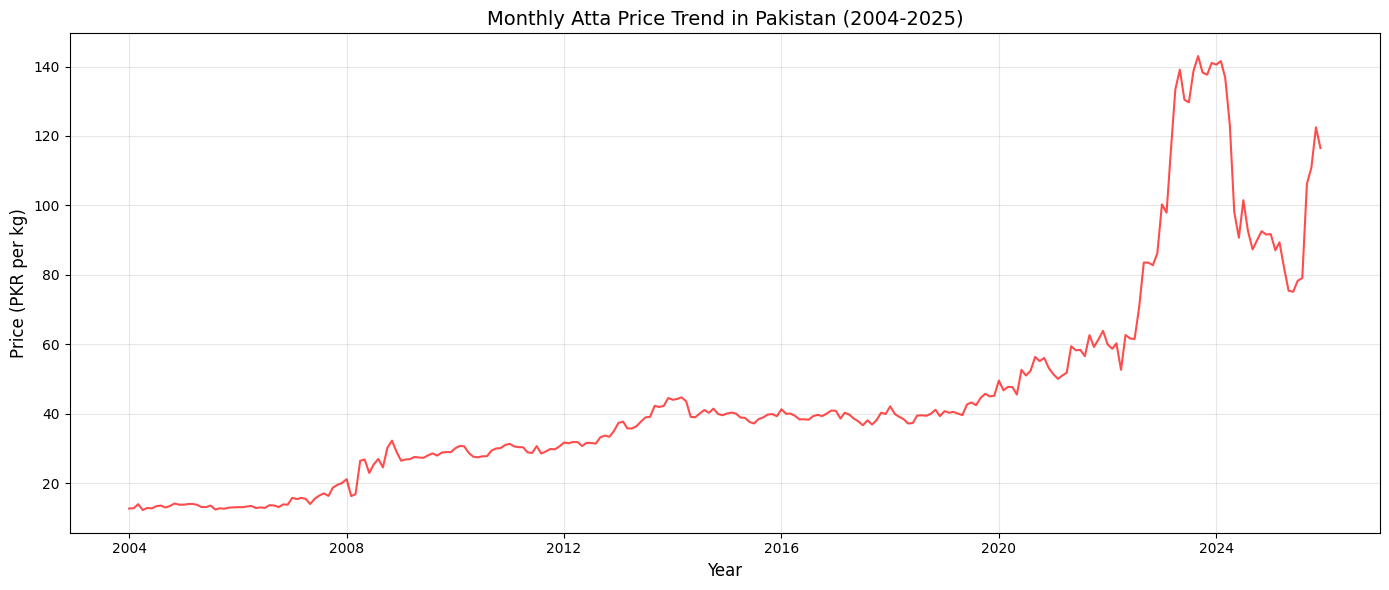

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load monthly merged data
df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['Wheat flour'], 'r-', linewidth=1.5, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (PKR per kg)', fontsize=12)
plt.title('Monthly Atta Price Trend in Pakistan (2004-2025)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1195/378313945.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(df['date'], df['Sugar'], 'g-', linewidth=1.5, color='darkgreen')


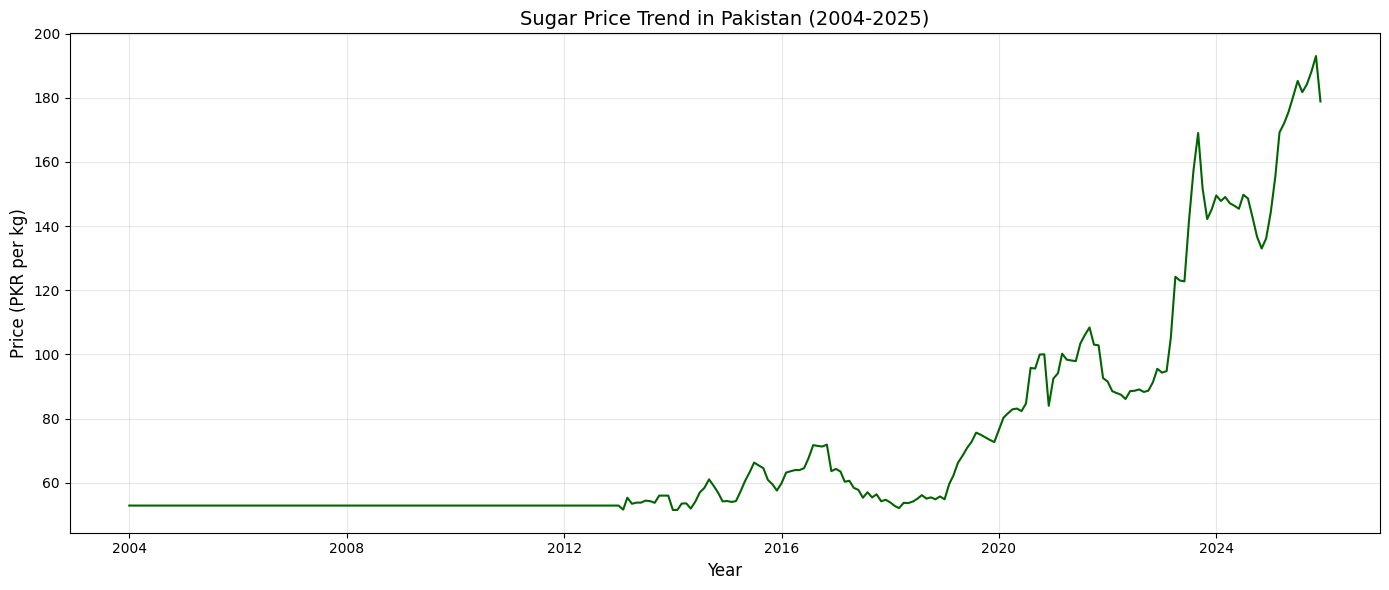

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['Sugar'], 'g-', linewidth=1.5, color='darkgreen')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (PKR per kg)', fontsize=12)
plt.title('Sugar Price Trend in Pakistan (2004-2025)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

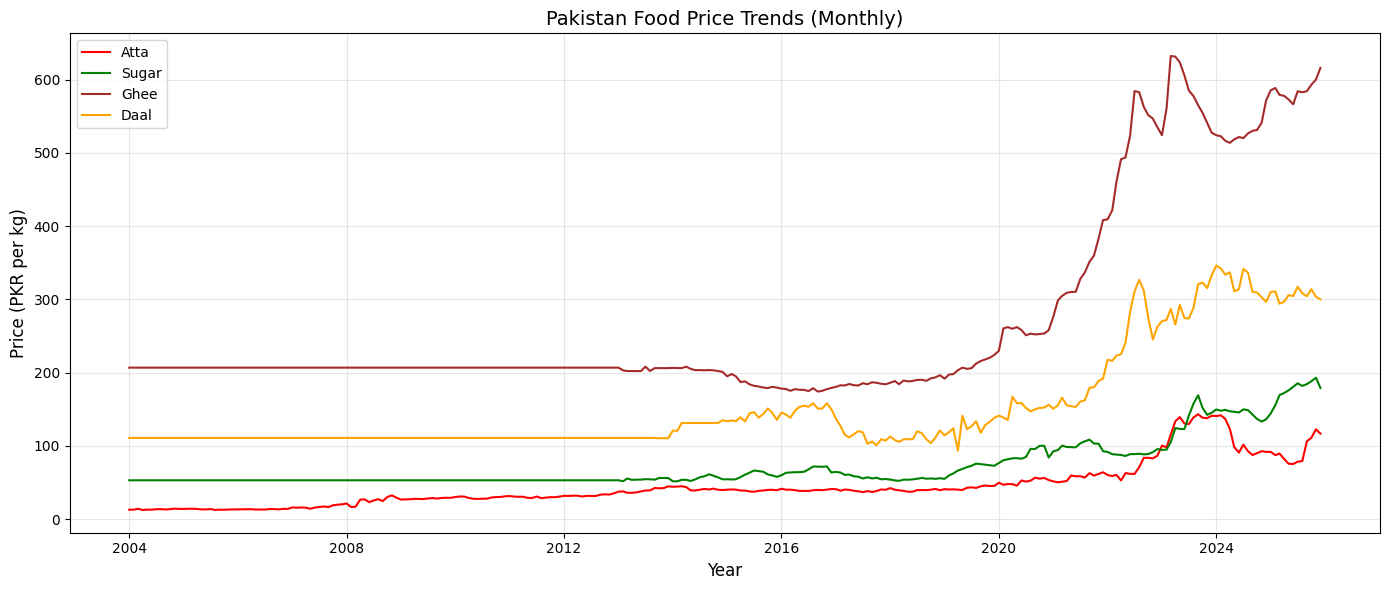

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['Wheat flour'], 'r-', linewidth=1.5, label='Atta')
plt.plot(df['date'], df['Sugar'], 'g-', linewidth=1.5, label='Sugar')
plt.plot(df['date'], df['Ghee (artificial)'], 'brown', linewidth=1.5, label='Ghee')
plt.plot(df['date'], df['Lentils (masur)'], 'orange', linewidth=1.5, label='Daal')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (PKR per kg)', fontsize=12)
plt.title('Pakistan Food Price Trends (Monthly)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

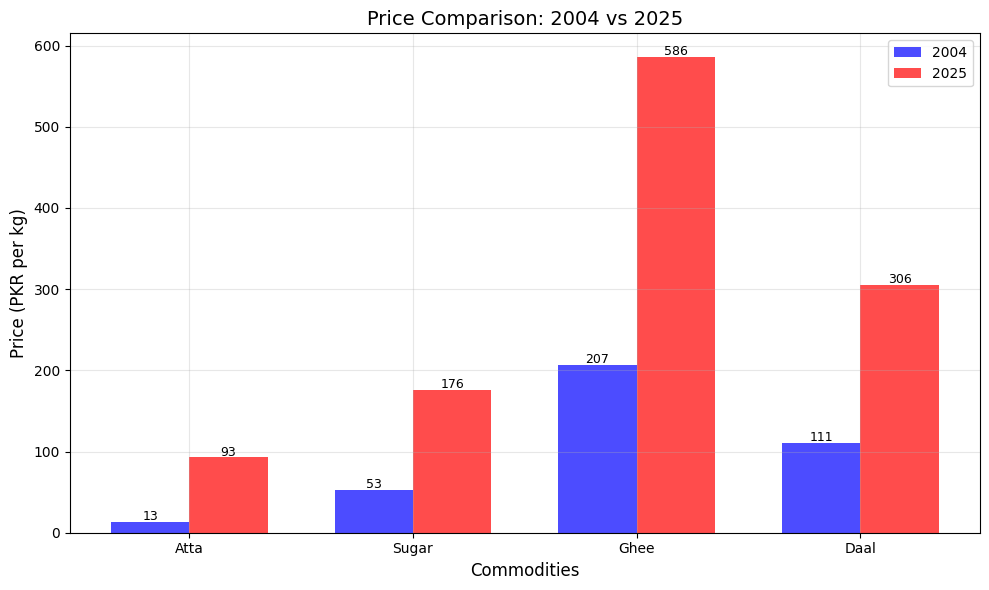


📊 Percentage Increase (2004 to 2025):
   Atta: 602%
   Sugar: 232%
   Ghee: 183%
   Daal: 176%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Get yearly averages
yearly = df.groupby('year').agg({
    'Wheat flour': 'mean',
    'Sugar': 'mean',
    'Ghee (artificial)': 'mean',
    'Lentils (masur)': 'mean'
}).reset_index()

# Get 2004 and 2025 prices
p2004 = yearly[yearly['year'] == 2004].iloc[0]
p2025 = yearly[yearly['year'] == 2025].iloc[0]

commodities = ['Wheat flour', 'Sugar', 'Ghee (artificial)', 'Lentils (masur)']
labels = ['Atta', 'Sugar', 'Ghee', 'Daal']
prices_2004 = [p2004[col] for col in commodities]
prices_2025 = [p2025[col] for col in commodities]

x = range(len(commodities))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], prices_2004, width, label='2004', color='blue', alpha=0.7)
plt.bar([i + width/2 for i in x], prices_2025, width, label='2025', color='red', alpha=0.7)

plt.xlabel('Commodities', fontsize=12)
plt.ylabel('Price (PKR per kg)', fontsize=12)
plt.title('Price Comparison: 2004 vs 2025', fontsize=14)
plt.xticks(x, labels)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for i, (v2004, v2025) in enumerate(zip(prices_2004, prices_2025)):
    plt.text(i - width/2, v2004 + 2, f'{v2004:.0f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2025 + 2, f'{v2025:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print percentage increases
print("\n📊 Percentage Increase (2004 to 2025):")
for i, label in enumerate(labels):
    increase = ((prices_2025[i] - prices_2004[i]) / prices_2004[i]) * 100
    print(f"   {label}: {increase:.0f}%")

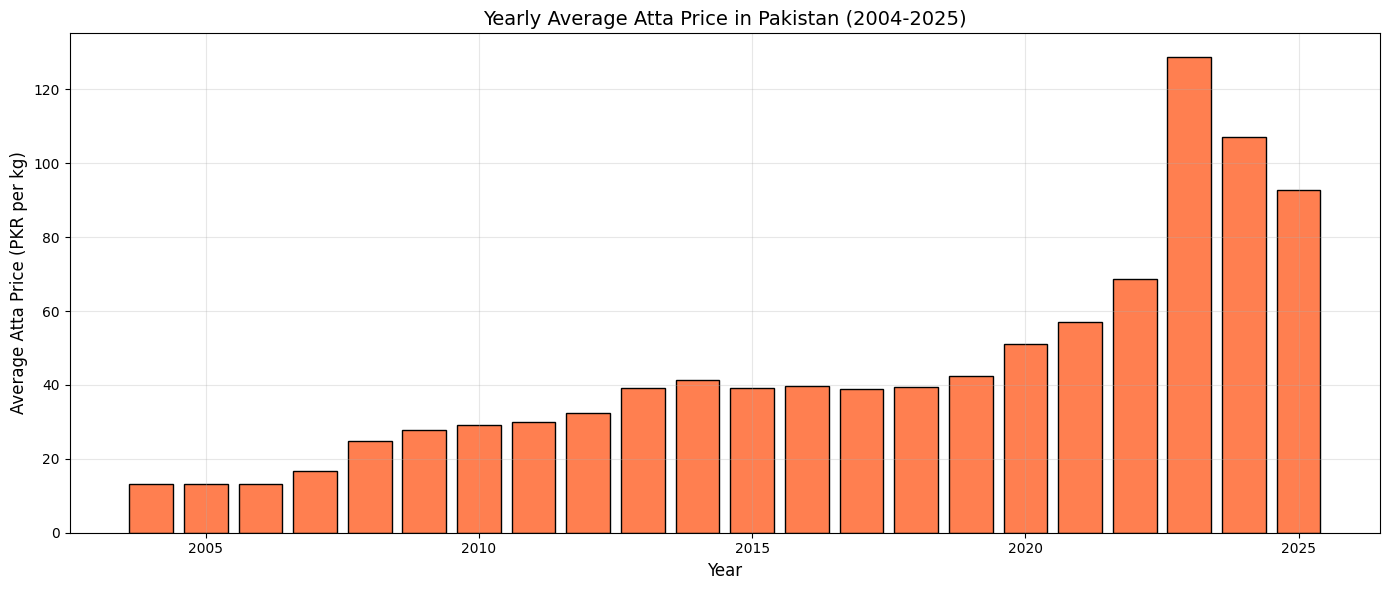

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("wfp_worldbank_monthly_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Calculate yearly averages
yearly = df.groupby('year')['Wheat flour'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.bar(yearly['year'], yearly['Wheat flour'], color='coral', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Atta Price (PKR per kg)', fontsize=12)
plt.title('Yearly Average Atta Price in Pakistan (2004-2025)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()